# Supplementary for Efficacy-at-Recurrent Input

Kai Sandbrink

2025-11-07

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
from utils import format_axis

if os.getcwd().endswith('scripts'):
    os.chdir('..')

analysis_folder = os.path.join('panels', 'fig_nns')
os.makedirs(analysis_folder, exist_ok=True)

effs = np.arange(0, 1.1, 0.125)

## Panel A: Learning Curves

In [23]:
from settings_ana import pepe_nn_efficacy_at_recurrent_models as ape_models

ape_modelname = ape_models[0]


eval_folder = os.path.join('data', 'nns', 'eval', 'pepe')

### APE MODEL

from settings_ana import pepe_nn_efficacy_at_recurrent_lc_timestamp as eval_timestamp

ape_test_rews = []
ape_test_apes_losses = []
ape_test_returns_losses = []
ape_test_apes_mses = []

for ape_model in ape_models:
    ape_test_rews.append(pickle.load(open(os.path.join(eval_folder, str(ape_model), eval_timestamp + '_test_learning_curve_rews.pkl'), 'rb')))
    ape_test_returns_losses.append(pickle.load(open(os.path.join(eval_folder, str(ape_model), eval_timestamp + '_test_learning_curve_returns_losses.pkl'), 'rb')))
    ape_test_apes_losses.append(pickle.load(open(os.path.join(eval_folder, str(ape_model), eval_timestamp + '_test_learning_curve_apes_losses.pkl'), 'rb')))
    ape_test_apes_mses.append(pickle.load(open(os.path.join(eval_folder, str(ape_model), eval_timestamp + '_test_learning_curve_apes_mses.pkl'), 'rb')))

test_episodes = pickle.load(open(os.path.join(eval_folder, str(ape_modelname), eval_timestamp + '_test_learning_curve_episodes.pkl'), 'rb'))

## average out along efficacy settings
ape_test_rews = np.array(ape_test_rews).mean(axis=2)

### THEORY
rews_pomdp = [25,25,25.33,26.12,27.05,28.06,29.13,30.23,31.36]


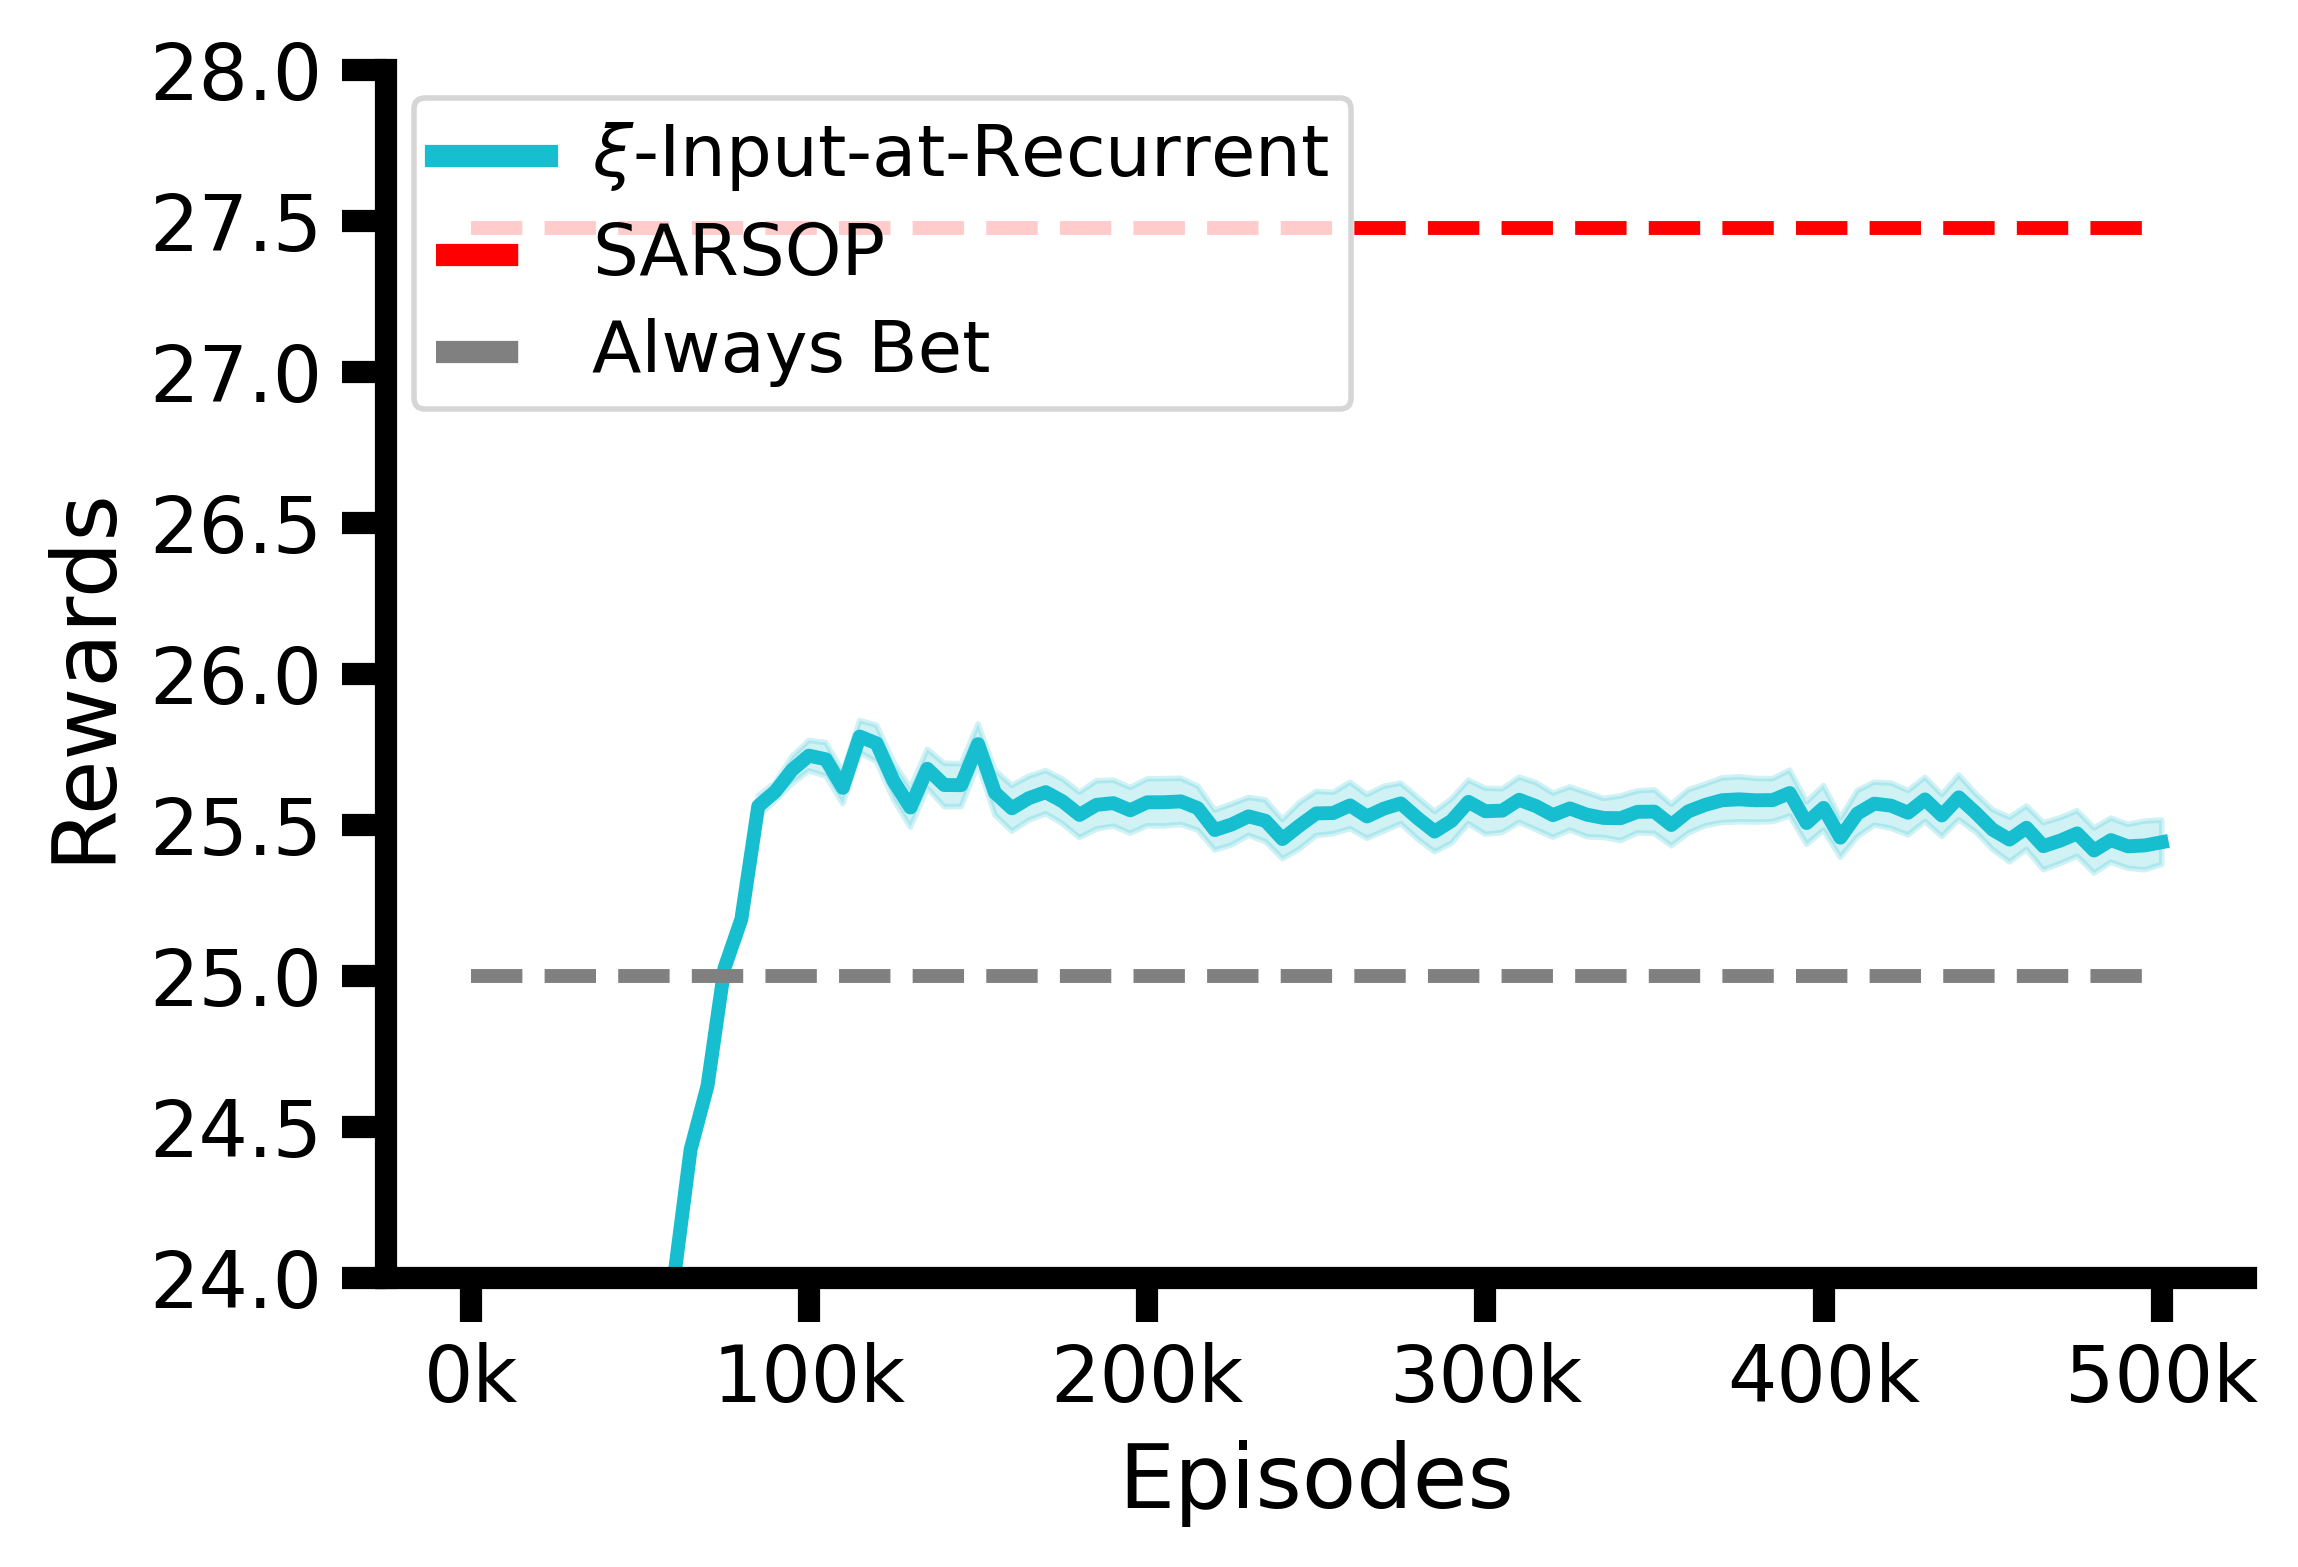

In [25]:
from matplotlib.ticker import FormatStrFormatter
from settings_ana import colors
from settings_ana import names

x_units = 'k'
x_exp = np.array(test_episodes) / 1000  # in 'k' episodes
y_exp = ape_test_rews.T

### preprocessing
y_exp = np.array(y_exp)
means_exp = y_exp.mean(axis=1)
stderr_exp = y_exp.std(axis=1)/np.sqrt(len(y_exp))

y_pomdp = [np.array(rews_pomdp).mean()]*len(x_exp)

y_always_bet = [25]*len(x_exp)

### set up figure
fig = plt.figure(dpi=400)
ax = fig.add_subplot(111)    

### plot
ax.plot(x_exp, means_exp, color=colors['efficacy_at_recurrent'], label=names['efficacy_at_recurrent'])
ax.fill_between(x_exp, means_exp - stderr_exp, means_exp + stderr_exp, color=colors['efficacy_at_recurrent'], alpha=0.2)

ax.plot(x_exp, y_pomdp, color='red', label=names['sarsop'], linestyle='--')

ax.plot(x_exp, y_always_bet, color='grey', label='Always Bet', linestyle='--')

### format axis
ax.set_xlabel('Episodes')
ax.set_ylabel('Rewards')

ax.xaxis.set_major_formatter(FormatStrFormatter('%dk'))

ax.legend(loc='upper left')

ax.set_ylim((24,28))

format_axis(ax)

In [26]:
fig.savefig(os.path.join(analysis_folder, 'efficacy_at_recurrent_learning_curves.png'))
fig.savefig(os.path.join(analysis_folder, 'efficacy_at_recurrent_learning_curves.svg'))

## Panel B: Number of Observes per Episode 

In [15]:
from settings_ana import pepe_nn_efficacy_at_recurrent_models as ape_models
from utils_project import load_modelrun_files
from settings_ana import timestamps

traj_base = os.path.join('data', 'nns', 'eval', 'pepe', )

cmap_apes = mpl.colormaps['Blues']
cmap_controls = mpl.colormaps['Oranges']
test_taus = np.arange(0, 1.1, 0.125)

rewss_taus_ape, counterss_peeks_taus_ape, control_errss_taus_ape, trajss_actions_taus_ape, trajss_logits_taus_ape, trajss_ps_taus_ape = load_modelrun_files(ape_models, timestamps['pepe_nn_efficacy_at_recurrent_traj'], ape=True, traj_base=traj_base)
    
peeks_pomdp = [0, 0, 0, 0, 4, 5, 5, 6, 7]

peeks_pomdp = np.array([
    [0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0],
    [0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0],
    [2,	2,	2,	2,	2,	2,	2,	2,	2,	2,	2,	2,	2,	2],
    [3,	3,	3,	3,	3,	3,	3,	3,	3,	3,	3,	3,	3,	3],
    [4,	4,	4,  4,	4,	4,	4,	4,	4,	4,	4,	4,	4,	4],
    [4,	4,	4,	4,	4,	4,	4,	4,	4,	4,	4,	4,	4,	4],
    [5,	5,	5,	5,	5,	5,	5,	5,	5,	5,	5,	5,	5,	5],
    [5,	5,	6,	5,	5,	5,	5,	5,	5,	5,	6,	5,	5,	5],
    [6,	6,	5,	5,	6,	5,	6,	6,	6,	6,	6,	5,	5,	6],
]).mean(axis=1)

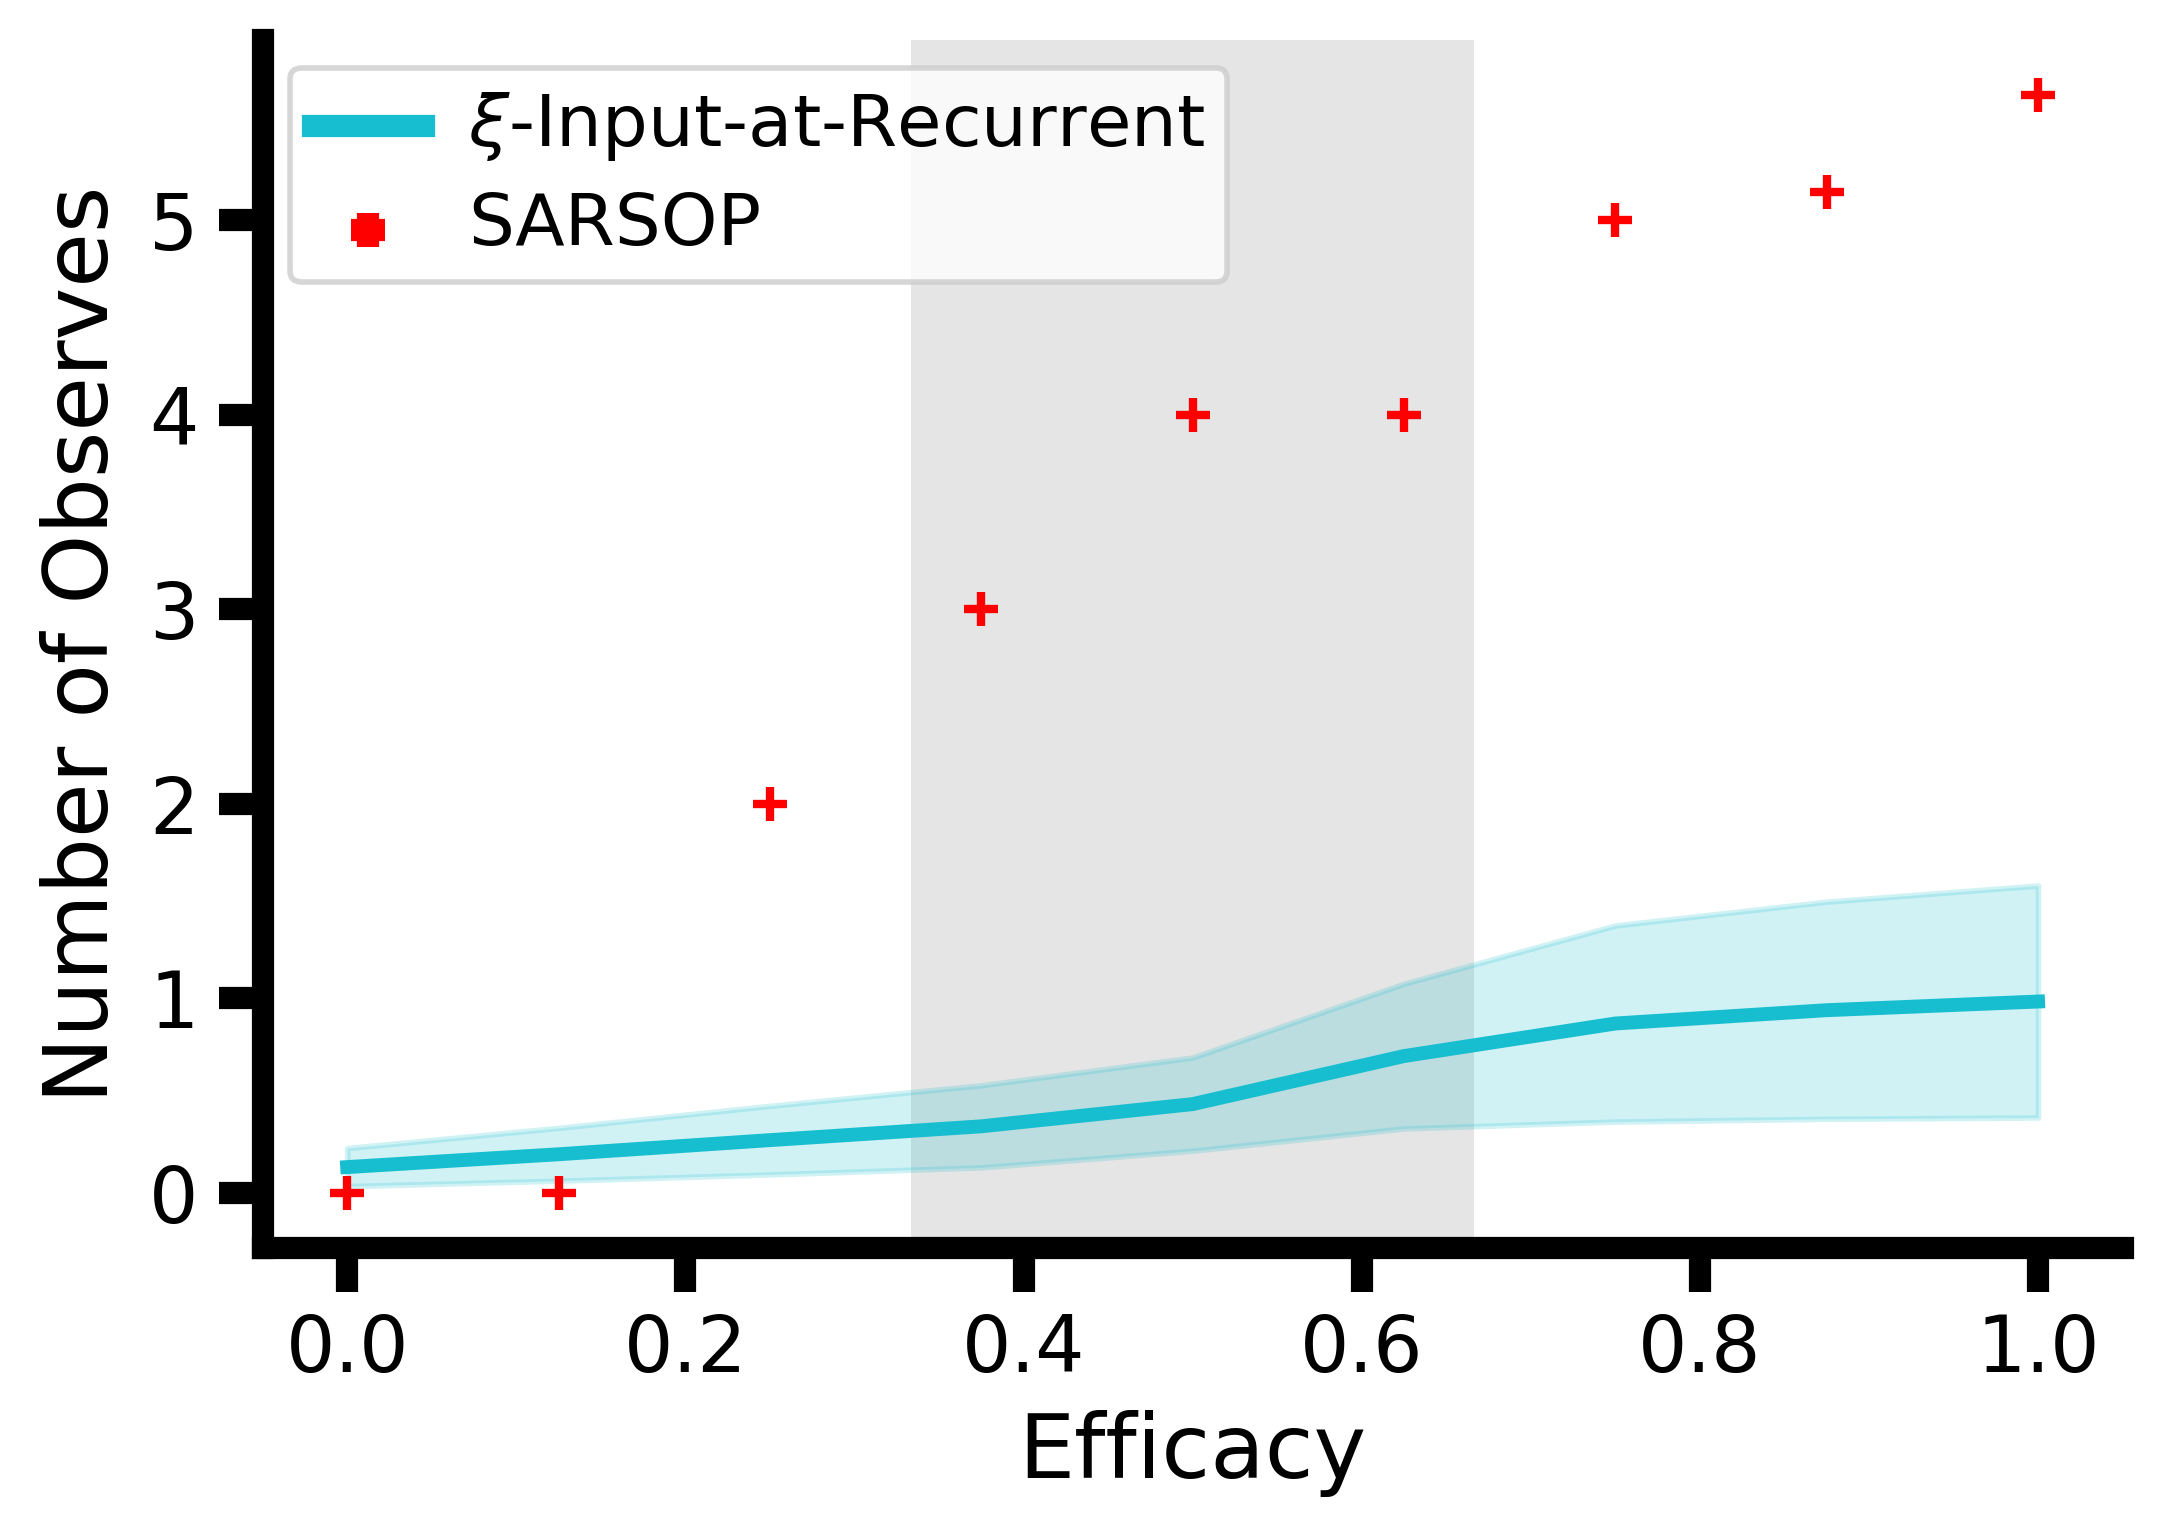

In [16]:
from test_analyses import plot_comparison_curves_several_runs
from settings_ana import colors
from settings_ana import names

fig = plot_comparison_curves_several_runs(test_taus, list(reversed(counterss_peeks_taus_ape)), 
                                          x_theory = test_taus, y_theory = peeks_pomdp, 
                                          label_theory = 'SARSOP', 
                                          axis_xlabel='Efficacy', axis_ylabel='Number of Observes', 
                                          label_exp=names['efficacy_at_recurrent'],
                                          color_exp=colors['efficacy_at_recurrent'],
                                          shaded_intervals=[(1/3, 2/3)],
                                          )

In [17]:
fig.savefig(os.path.join(analysis_folder, 'efficacy_at_recurrent_observes_across.png'))
fig.savefig(os.path.join(analysis_folder, 'efficacy_at_recurrent_observes_across.svg'))

## Panel C: Rewards Across Episodes

In [18]:
from settings_ana import pepe_nn_efficacy_at_recurrent_models as ape_models
from utils_project import load_modelrun_files
from settings_ana import pepe_nn_efficacy_at_recurrent_traj_timestamp as traj_timestamp
from settings_ana import timestamps

traj_base = os.path.join('data', 'nns', 'eval', 'pepe', )

test_taus = np.arange(0, 1.1, 0.125)

rewss_taus_ape, counterss_peeks_taus_ape, control_errss_taus_ape, trajss_actions_taus_ape, trajss_logits_taus_ape, trajss_ps_taus_ape = load_modelrun_files(ape_models, traj_timestamp, ape=True, traj_base=traj_base)

rews_pomdp = [25,25,25.33,26.12,27.05,28.06,29.13,30.23,31.36]


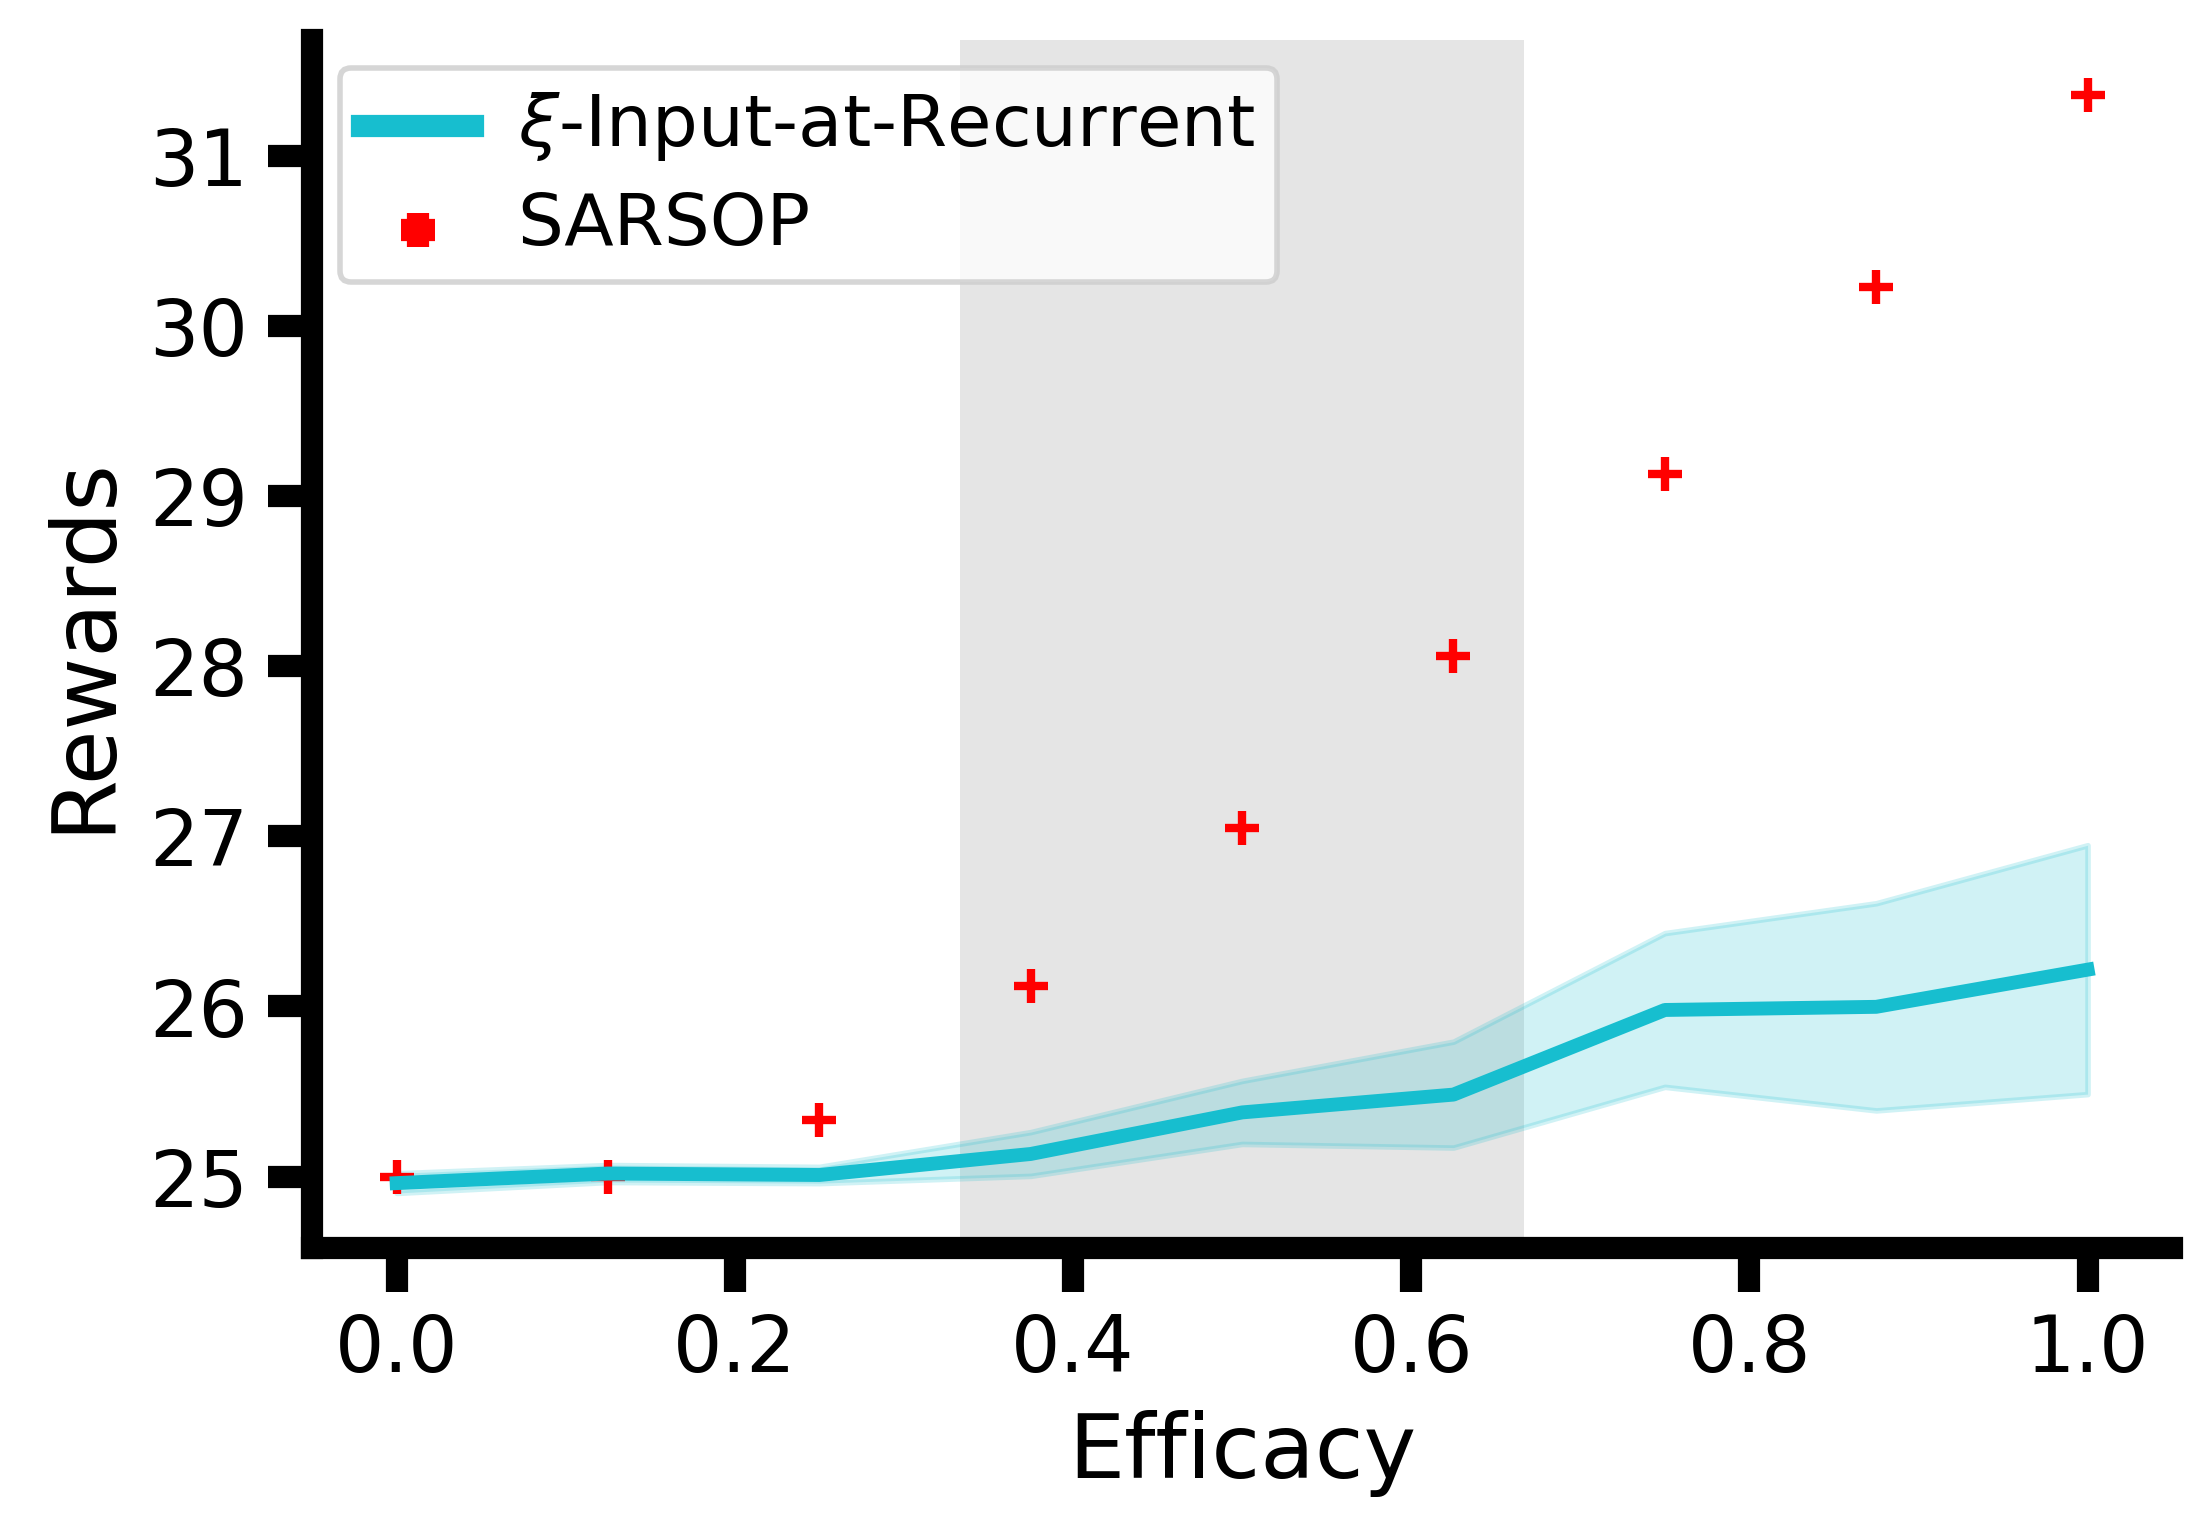

In [19]:
from test_analyses import plot_comparison_curves_several_runs
from settings_ana import colors
from settings_ana import names

fig = plot_comparison_curves_several_runs(test_taus, list(reversed(rewss_taus_ape)),
                                          x_theory = test_taus, y_theory = rews_pomdp,
                                            label_theory = 'SARSOP', 
                                            axis_xlabel='Efficacy', axis_ylabel='Rewards', 
                                            label_exp=names['efficacy_at_recurrent'],
                                            color_exp=colors['efficacy_at_recurrent'],
                                            shaded_intervals=[(1/3, 2/3)],)

In [20]:
fig.savefig(os.path.join(analysis_folder, 'efficacy_at_recurrent_rewards_across.png'))
fig.savefig(os.path.join(analysis_folder, 'efficacy_at_recurrent_rewards_across.svg'))